In [8]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [9]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_Week1\core-metrics-results-24576

C:\Users\tr432\Downloads\filter_GutLungAxis_Week1\core-metrics-results-24576


In [10]:
## '#SampleID' 열 & 'Group' 열 있어야됨
meta = pd.read_csv('../RUN45_Metadata_GutLungAxis.txt', sep='\t')

## pcoa.qza export하면 생기는 ordination.txt 파일 그대로 가져다 쓰면됨
df_uw = pd.read_csv('unweighted_unifrac_pcoa_results/ordination.txt', sep='\t', skiprows=8, usecols=range(3))
df_w = pd.read_csv('weighted_unifrac_pcoa_results/ordination.txt', sep='\t', skiprows=8, usecols=range(3))
df_bray = pd.read_csv('bray_curtis_pcoa_results/ordination.txt', sep='\t', skiprows=8, usecols=range(3))
df_jaccard = pd.read_csv('jaccard_pcoa_results/ordination.txt', sep='\t', skiprows=8, usecols=range(3))


mapping = meta.set_index('#SampleID')['Group']
df_uw['Site'] = df_uw['Site'].map(mapping)
df_uw = df_uw.dropna(subset=['Site'])
df_uw.columns = ['Group', 'PC1', 'PC2']

mapping = meta.set_index('#SampleID')['Group']
df_w['Site'] = df_w['Site'].map(mapping)
df_w = df_w.dropna(subset=['Site'])
df_w.columns = ['Group', 'PC1', 'PC2']

mapping = meta.set_index('#SampleID')['Group']
df_bray['Site'] = df_bray['Site'].map(mapping)
df_bray = df_bray.dropna(subset=['Site'])
df_bray.columns = ['Group', 'PC1', 'PC2']

mapping = meta.set_index('#SampleID')['Group']
df_jaccard['Site'] = df_jaccard['Site'].map(mapping)
df_jaccard = df_jaccard.dropna(subset=['Site'])
df_jaccard.columns = ['Group', 'PC1', 'PC2']

print(meta.head(3))
print(df_uw.head(3))
print(df_w.head(3))
print(df_bray.head(3))
print(df_jaccard.head(3))

  #SampleID subject    Subject_ID ExpNo MouseNo MouseNo2     MouseStrain Sex  \
0    C01-1w  C01-1w  Exp1_C1-2_1w  Exp1    C1-2      C01  C57BL/6NCrlOri   M   
1    C01-2w  C01-2w  Exp1_C1-2_2w  Exp1    C1-2      C01  C57BL/6NCrlOri   M   
2    C02-1w  C02-1w  Exp1_C2-1_1w  Exp1    C2-1      C02  C57BL/6NCrlOri   M   

  Age CageNo  ... ExpNo+Group ExpNo+SamplingWeek Group+SamplingWeek  \
0  8W     C1  ...    Exp1_Con         Exp1_Week1          Con_Week1   
1  9W     C1  ...    Exp1_Con         Exp1_Week2          Con_Week2   
2  8W     C2  ...    Exp1_Con         Exp1_Week1          Con_Week1   

  ExpNo+Group+SamplingWeek AIM BM_whole   BM_wbc Spleen   b.w Spleen/b.w  
0           Exp1_Con_Week1 NaN      NaN  1960000   64.0  22.8       2.81  
1           Exp1_Con_Week2 NaN      NaN  1960000   64.0  22.8       2.81  
2           Exp1_Con_Week1 NaN      NaN   970000  136.0  23.4       5.81  

[3 rows x 27 columns]
     Group       PC1       PC2
0  Control -0.254152  0.052608
1  Contro

In [11]:
## Beta-Diveristy PCoA plot의 Ellipse를 함수로 지정
def plot_confidence_ellipse(data, confidence_level=0.90):
    # 중심점 계산
    mean_x, mean_y = np.mean(data, axis=0)
    
    # 공분산 행렬 계산
    cov_matrix = np.cov(data, rowvar=False)
    
    # 고유값 분해
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)
    
    # 신뢰도 수준 스케일링
    # 90% 신뢰 구간을 위해 chi-square 값의 제곱근을 사용 (2차원에서는 약 4.605)
    if confidence_level == 0.95 :
        chi_square_val = 5.991
    elif confidence_level == 0.90 :
        chi_square_val = 4.605
    elif confidence_level == 0.8 :
        chi_square_val = 3.219
    else:
        raise ValueError('CI')

    scale = np.sqrt(chi_square_val)
    
    # 반지름 계산
    width, height = 2 * scale * np.sqrt(eigvals)
    
    # 타원의 회전각 계산 (라디안에서 도 단위로 변환)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    return (mean_x, mean_y), width, height, angle

def cal_ellipse(data, group_name, component1='Component1', componet2='Component2', cl=0.9):
    data = data[data.Group == group_name]
    data = data[[component1, componet2]].values

    (mean_x, mean_y), width, height, angle = plot_confidence_ellipse(data, confidence_level=cl)

    return (mean_x, mean_y), width, height, angle

In [12]:
## Group 종류 확인
print(df_uw.Group.unique())
print(df_w.Group.unique())
print(df_bray.Group.unique())
print(df_jaccard.Group.unique())

['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']


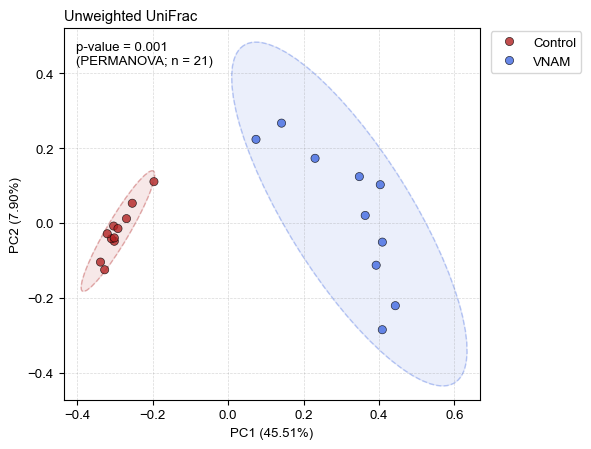

In [13]:
## Unweighted UniFrac PCoA


palette = ['firebrick', 'royalblue']  ## 아래의 is_ellipse에서 지정한 색 순서랑 일치해야됨

marker_size = 35
alpha = 0.8
is_ellipse = True

#fig, ax = plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(5, 4.6))

data = df_uw


if is_ellipse:
    alpha=0.1

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Control', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='firebrick', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='royalblue', alpha=alpha)
    ax.add_patch(ellipse)


    alpha=0.3

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Control', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='none', alpha=alpha, linestyle='--')
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='none', alpha=alpha, linestyle='--')
    ax.add_patch(ellipse)


alpha = 0.8
sns.scatterplot(data=data, x='PC1', y='PC2', hue='Group', s=marker_size, alpha=alpha, edgecolor='k', palette=palette)


prop = pd.read_csv('unweighted_unifrac_pcoa_results/ordination.txt', sep='\t', header=None, usecols=range(2))
pc1 = float(prop.iloc[3,0]) * 100
pc2 = float(prop.iloc[3,1]) * 100


if True:
    plt.title('Unweighted UniFrac', loc='left', fontsize=10.5)
    plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=9.5)
    plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=9.5)
    plt.xticks(fontsize=9.5,)
    plt.yticks(fontsize=9.5)
    legend1 = plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.01), fontsize=9.5)  ## loc='upper right' 로 바꾸면 legend가 plot 안으로 들어감
    label = f'p-value = 0.001\n(PERMANOVA; n = {df_uw.shape[0]})'  #Edit: p-value 값 바꾸고 df 이름 바꾸기
    legend2 = plt.legend([], [], title=label, loc='upper left', frameon=False, title_fontsize=9.5)  #Edit: loc 위치 적절하게 조절
    fig.add_artist(legend1)
#    plt.gca().get_legend().remove()

#    plt.yticks([-0.3, -0.15, 0, 0.15, 0.3])
#    plt.xlim(-0.8, 0.5)
#    plt.ylim(-0.5, 0.45)


    plt.tight_layout()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#    plt.savefig('../uw.tiff', dpi=300, bbox_inches='tight')  ## bbox_inches='tight' 은 bbox_to_anchor=(1.01, 1.01) 때문에 legend가 잘리는걸 방지해줌

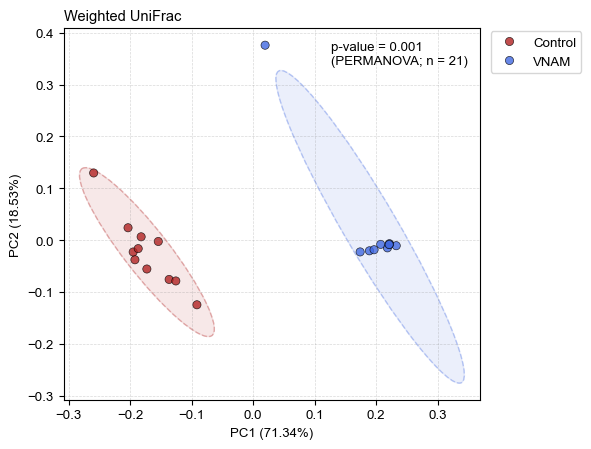

In [14]:
## Weighted UniFrac PCoA


palette = ['firebrick', 'royalblue']

marker_size = 35
alpha = 0.8
is_ellipse = True

#fig, ax = plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(5, 4.6))

data = df_w


if is_ellipse:
    alpha=0.1

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Control', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='firebrick', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='royalblue', alpha=alpha)
    ax.add_patch(ellipse)


    alpha=0.3

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Control', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='none', alpha=alpha, linestyle='--')
    ax.add_patch(ellipse)
    
    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='none', alpha=alpha, linestyle='--')
    ax.add_patch(ellipse)


alpha = 0.8
sns.scatterplot(data=data, x='PC1', y='PC2', hue='Group', s=marker_size, alpha=alpha, edgecolor='k', palette=palette)


prop = pd.read_csv('weighted_unifrac_pcoa_results/ordination.txt', sep='\t', header=None, usecols=range(2))
pc1 = float(prop.iloc[3,0]) * 100
pc2 = float(prop.iloc[3,1]) * 100


if True:
    plt.title('Weighted UniFrac', loc='left', fontsize=10.5)
    plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=9.5)
    plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=9.5)
    plt.xticks(fontsize=9.5,)
    plt.yticks(fontsize=9.5)
    legend1 = plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.01), fontsize=9.5)
    label = f'p-value = 0.001\n(PERMANOVA; n = {df_w.shape[0]})'  #Edit
    legend2 = plt.legend([], [], title=label, loc='upper right', frameon=False, title_fontsize=9.5)  #Edit
    fig.add_artist(legend1)
#    plt.gca().get_legend().remove()

#    plt.yticks([-0.3, -0.15, 0, 0.15, 0.3])
#    plt.xlim(-0.4, 0.6)
#    plt.ylim(-0.4, 0.6)


    plt.tight_layout()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#    plt.savefig('../w.tiff', dpi=300, bbox_inches='tight')

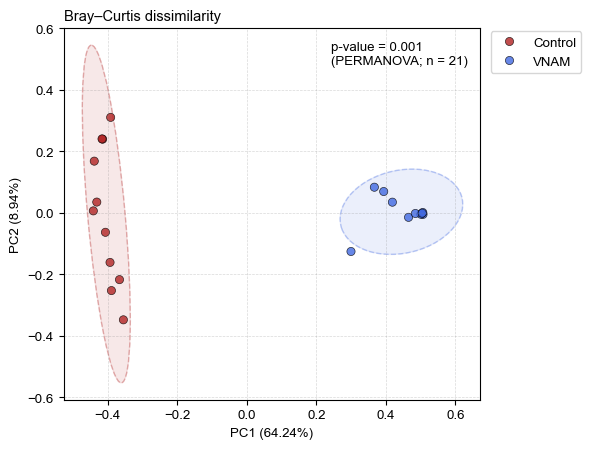

In [15]:
## Bray–Curtis dissimilarity PCoA


palette = ['firebrick', 'royalblue']

marker_size = 35
alpha = 0.8
is_ellipse = True

#fig, ax = plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(5, 4.6))

data = df_bray


if is_ellipse:
    alpha=0.1

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Control', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='firebrick', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='royalblue', alpha=alpha)
    ax.add_patch(ellipse)


    alpha=0.3

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Control', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='none', alpha=alpha, linestyle='--')
    ax.add_patch(ellipse)
    
    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='none', alpha=alpha, linestyle='--')
    ax.add_patch(ellipse)


alpha = 0.8
sns.scatterplot(data=data, x='PC1', y='PC2', hue='Group', s=marker_size, alpha=alpha, edgecolor='k', palette=palette)


prop = pd.read_csv('bray_curtis_pcoa_results/ordination.txt', sep='\t', header=None, usecols=range(2))
pc1 = float(prop.iloc[3,0]) * 100
pc2 = float(prop.iloc[3,1]) * 100


if True:
    plt.title('Bray–Curtis dissimilarity', loc='left', fontsize=10.5)
    plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=9.5)
    plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=9.5)
    plt.xticks(fontsize=9.5,)
    plt.yticks(fontsize=9.5)
    legend1 = plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.01), fontsize=9.5)
    label = f'p-value = 0.001\n(PERMANOVA; n = {df_bray.shape[0]})'  #Edit
    legend2 = plt.legend([], [], title=label, loc='upper right', frameon=False, title_fontsize=9.5)  #Edit
    fig.add_artist(legend1)
#    plt.gca().get_legend().remove()

#    plt.yticks([-0.3, -0.15, 0, 0.15, 0.3])
#    plt.xlim(-0.4, 0.6)
#    plt.ylim(-0.4, 0.6)


    plt.tight_layout()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#    plt.savefig('../bray.tiff', dpi=300, bbox_inches='tight')

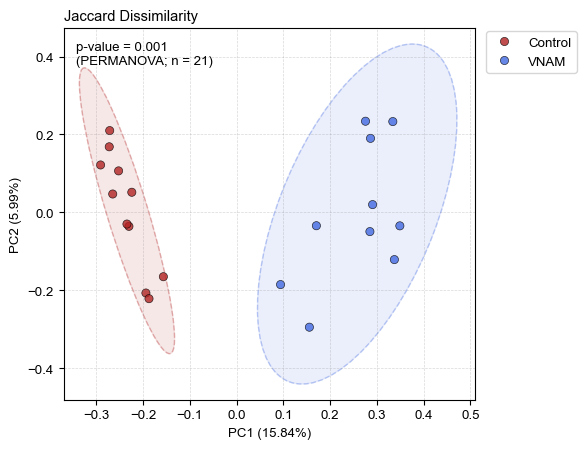

In [16]:
## Jaccard PCoA


palette = ['firebrick', 'royalblue']

marker_size = 35
alpha = 0.8
is_ellipse = True

#fig, ax = plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(5, 4.6))

data = df_jaccard


if is_ellipse:
    alpha=0.1

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Control', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='firebrick', alpha=alpha)
    ax.add_patch(ellipse)

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='royalblue', alpha=alpha)
    ax.add_patch(ellipse)


    alpha=0.3

    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='Control', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='firebrick', facecolor='none', alpha=alpha, linestyle='--')
    ax.add_patch(ellipse)
    
    (mean_x, mean_y), width, height, angle = cal_ellipse(data, group_name='VNAM', cl=0.95, component1='PC1', componet2='PC2')  #Edit
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, edgecolor='royalblue', facecolor='none', alpha=alpha, linestyle='--')
    ax.add_patch(ellipse)


alpha = 0.8
sns.scatterplot(data=data, x='PC1', y='PC2', hue='Group', s=marker_size, alpha=alpha, edgecolor='k', palette=palette)


prop = pd.read_csv('jaccard_pcoa_results/ordination.txt', sep='\t', header=None, usecols=range(2))
pc1 = float(prop.iloc[3,0]) * 100
pc2 = float(prop.iloc[3,1]) * 100


if True:
    plt.title('Jaccard Dissimilarity', loc='left', fontsize=10.5)
    plt.xlabel(f'PC1 ({pc1:.2f}%)', fontsize=9.5)
    plt.ylabel(f'PC2 ({pc2:.2f}%)', fontsize=9.5)
    plt.xticks(fontsize=9.5,)
    plt.yticks(fontsize=9.5)
    legend1 = plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.01), fontsize=9.5)
    label = f'p-value = 0.001\n(PERMANOVA; n = {df_jaccard.shape[0]})'  #Edit
    legend2 = plt.legend([], [], title=label, loc='upper left', frameon=False, title_fontsize=9.5)  #Edit
    fig.add_artist(legend1)
#    plt.gca().get_legend().remove()

#    plt.yticks([-0.3, -0.15, 0, 0.15, 0.3])
#    plt.xlim(-0.4, 0.6)
#    plt.ylim(-0.4, 0.6)


    plt.tight_layout()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#    plt.savefig('../jaccard.tiff', dpi=300, bbox_inches='tight')